In [2]:
from nbodykit.lab import cosmology as n_cosmology
c      = n_cosmology.Planck15
c = c.clone(P_k_max=100)
#c = n_cosmology.Cosmology(h=0.67556, T0_cmb=2.7255, Omega0_b=0.0482754208891869, Omega0_cdm=0.26377065934278865, N_ur=None, m_ncdm=[0.06], P_k_max=100.0, P_z_max=100.0, gauge='synchronous', n_s=0.9667, nonlinear=False, verbose=False)
#Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')
Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')

Pnl = n_cosmology.power.halofit.HalofitPower(c, redshift=1.5) 
cf_lin = n_cosmology.CorrelationFunction(Plin)
cf_nl = n_cosmology.CorrelationFunction(Pnl)

In [11]:
import matplotlib.pyplot as plt
import numpy as np

In [6]:
import pickle


odir = "../ps_data"
with open(f"{odir}/dm/TNG300-3-Dark/snap40/test4.pickle", "rb") as f:
    Pk2 = pickle.load(f)
    
print("shotnoise", Pk2.attrs["shotnoise"])

shotnoise 0.035287552


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


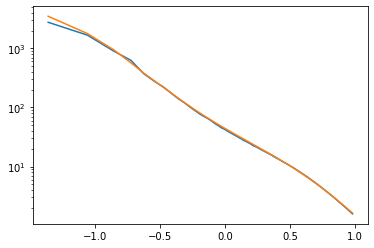

In [18]:
plt.plot(np.log10(Pk2["k"]), Pk2["power"])
plt.plot(np.log10(Pk2["k"]), Pnl(Pk2["k"]))
plt.yscale("log")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


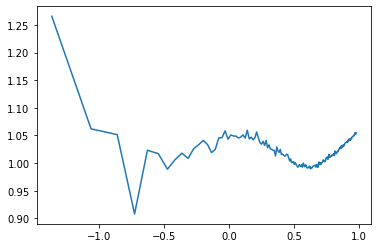

In [17]:
plt.plot(np.log10(Pk2["k"]), Pnl(Pk2["k"])/(Pk2["power"]-Pk2.attrs["shotnoise"]))

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


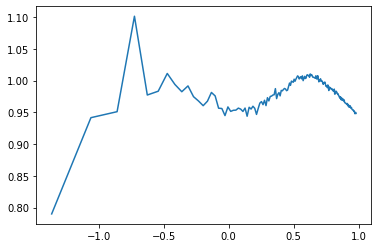

In [19]:
plt.plot(np.log10(Pk2["k"]), (Pk2["power"]-Pk2.attrs["shotnoise"])/Pnl(Pk2["k"]))